In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
from decimal import Decimal
import deepwave
import warnings
import psutil
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
os.environ['KMP_DUPLICATE_LIB_OK']='True'


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


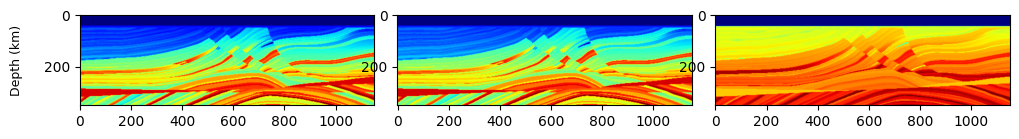

max values: tensor(4766.6040, device='cuda:0') tensor(2752., device='cuda:0') tensor(2626.9998, device='cuda:0')
min values: tensor(1500., device='cuda:0') tensor(800., device='cuda:0') tensor(1009., device='cuda:0')
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy')).to(DEVICE)
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy')).to(DEVICE)
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy')).to(DEVICE)


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

In [4]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  
N_SHOTS = 100                                             
N_SOURCE_PER_SHOT = 1                                    


inpa = {  
    'ns': N_SHOTS,                                   
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500#int( Decimal(t_in) // Decimal(dt_in)  + 1)
print("NT:",NT)
# -------------------------------
# Basic parameter definitions
# -------------------------------
# -------------------------------
# Basic parameter definitions
# -------------------------------
receiver_spacing =  inpa['dh']         # Distance between receivers
source_depth = 2 * inpa['dh']         # Depth of the source
receiver_depth = 2 * inpa['dh']      # Depth of the receivers

# -------------------------------
# Model dimensions
# -------------------------------
model_width = model_shape[1] * inpa['dh']   # Total model width in meters
model_depth = model_shape[0] * inpa['dh']   # Total model depth in meters

print("Model width (offsetx):", model_width)
print("Model depth:", model_depth)

# -------------------------------
# Define receiver coordinates (x evenly spaced, z fixed)
# -------------------------------
receiver_start_x = 10 * inpa['dh']
receiver_end_x = model_width - 10 * inpa['dh']
receiver_x = np.arange(receiver_start_x, receiver_end_x, receiver_spacing, dtype=np.float32)
num_receivers = len(receiver_x)
receiver_z = np.full(num_receivers, receiver_depth, dtype=np.float32)
receiver_coords = np.vstack((receiver_x, receiver_z)).T  # shape: [num_receivers, 2]

N_SHOT_ALL = N_SHOTS * N_SOURCE_PER_SHOT

# -------------------------------
# Define source coordinates (x evenly spaced, z fixed)
# -------------------------------
source_x = np.linspace(receiver_start_x, receiver_end_x, N_SHOT_ALL, dtype=np.float32)
source_z = np.full(N_SHOT_ALL, source_depth, dtype=np.float32)
source_coords = np.vstack((source_x, source_z)).T  # shape: [N_SHOTS, 2]

# Optionally shift sources upward (e.g., simulate shallower source depth)
#source_coords[:, 1] -= 2 * inpa['dh']

# -------------------------------
# Convert coordinates to torch integer grid indices [z, x]
# -------------------------------
src_loc = torch.zeros(N_SHOT_ALL, 1, 2, dtype=torch.int, device=DEVICE)
src_loc[:, 0, :] = torch.Tensor(np.flip(source_coords, axis=1) // inpa['dh'])


src_loc[:, :, 0] = 1  # Fix the z-index to 1 (simulate near-surface source)



# Set the same receivers for all shots
rec_loc = torch.zeros(N_SHOT_ALL, num_receivers, 2, dtype=torch.long, device=DEVICE)
receiver_tensor = torch.Tensor(np.flip(receiver_coords, axis=1) / inpa['dh'])  # shape: [num_receivers, 2]
rec_loc[:, :, :] = receiver_tensor.unsqueeze(0).repeat(N_SHOTS, 1, 1)

print('Number of receivers per shot:', num_receivers)
print('Receiver location tensor shape:', rec_loc.shape)
print('Source location tensor shape:', src_loc.shape)
#

np.save('./src_rec_positions/src_loc.npy',src_loc.detach().cpu().numpy())
np.save('./src_rec_positions/rec_loc.npy',rec_loc.detach().cpu().numpy())

src = (
    deepwave.wavelets.ricker(F_PEAK, NT, DT, 1.5 / F_PEAK)
    .repeat(N_SHOTS, N_SOURCE_PER_SHOT, 1)
    .to(DEVICE)
    ) 

NT: 2500
Model width (offsetx): 11500
Model depth: 3520
Number of receivers per shot: 1130
Receiver location tensor shape: torch.Size([100, 1130, 2])
Source location tensor shape: torch.Size([100, 1, 2])


In [5]:

lack_low_fre = 'yes'
cutoff_fre_l = 3
cutoff_fre_h = 15
corners = 12

noise_test = 'yes'
noise_level = 10  ### snr value


test_outers = 'no'
interval = 6           # Number of consecutive samples to zero when test_outers='yes'
iterval_1 = 20



if lack_low_fre == 'yes': 
    src = seismic_filter(data=src.cpu(), \
                           filter_type='bandpass',freqmin=cutoff_fre_l, \
                           freqmax=cutoff_fre_h,df=1/DT,corners=corners)
    src = torch.tensor(src).to(torch.float32).to(DEVICE)
else:
    src = src = torch.tensor(src).to(torch.float32)

np.save('./sources/src.npy',src.detach().cpu().numpy())

In [6]:
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'

try:
    if os.path.exists(obs_file_vx) and os.path.exists(obs_file_vy):
        d_obs_vx = torch.tensor(np.load(obs_file_vx)).to(DEVICE)
        d_obs_vy = torch.tensor(np.load(obs_file_vy)).to(DEVICE)
        print(f"loading data: {obs_file_vx}, {obs_file_vy}")
    else:
        raise FileNotFoundError("data does not exist")
except (FileNotFoundError, IOError) as e:
    print(f"Failed to load data: {e}")
    print("Data is being generated...")

    deepwave_size= NT
    physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=deepwave_size,src=src,
                        src_loc=src_loc, rec_loc=rec_loc
                        )
    taux_est = physics(vp_true,vs_true,rho_true)  
    d_obs_vx = taux_est[0]
    d_obs_vy = taux_est[1]

    print(f"vx shape: {d_obs_vx.shape}, vy shape: {d_obs_vy.shape}")
    
    # 3. Add Gaussian noise if specified
    if noise_test == 'yes':
        d_obs_vx = AddAWGN(d_obs_vx.squeeze(0), noise_level).unsqueeze(0)
        d_obs_vy = AddAWGN(d_obs_vy.squeeze(0), noise_level).unsqueeze(0)
        print(f"Added Gaussian noise (σ={noise_level})")
    
    # 4. Zero out intervals if specified
    if test_outers == 'yes':
        for start in range(0, d_obs_vx.shape[2], iterval_1):  # Every 20 samples
            end = start + interval
            if end <= d_obs_vx.shape[2]:
                d_obs_vx[:, :, start:end] = 0
                d_obs_vy[:, :, start:end] = 0
        print(f"Zeroed {interval}-sample intervals every 20 samples")

    # 确保目录存在
    os.makedirs(os.path.dirname(obs_file_vx), exist_ok=True)
    # 保存数据
    np.save(obs_file_vx, d_obs_vx.detach().cpu().numpy())
    np.save(obs_file_vy, d_obs_vy.detach().cpu().numpy())
    print(f"Data is being saved")


Failed to load data: data does not exist
Data is being generated...
vx shape: torch.Size([1, 100, 2500, 1130]), vy shape: torch.Size([1, 100, 2500, 1130])
Added Gaussian noise (σ=10)
Data is being saved


torch.Size([100, 2500, 1130])


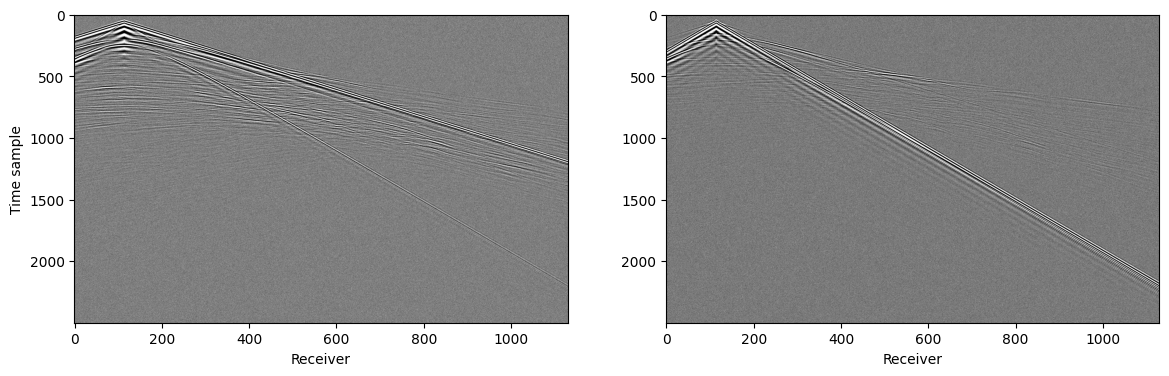

In [7]:
p = 10

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vy_plot = d_obs_vy.squeeze(0)
print(d_obs_vx_plot.shape)
vmin, vmax = torch.quantile(d_obs_vx_plot[p],
                            torch.tensor([0.01, 0.99]).to(DEVICE))
vsmin, vsmax = torch.quantile(d_obs_vy_plot[p],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[p].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vy_plot[p].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
# ax[1].set_ylabel("Time sample")
plt.subplots_adjust(hspace=0.6) 
#plt.savefig(Fig_path+f"/obs&input_gather"+".jpg", dpi=900)  
plt.show()
